# Deep Neural Networks

The Universal Approximation Theorem states that a feedforward neural network with a single hidden layer, given sufficiently many neurons and a nonlinear activation function (e.g., sigmoid or ReLU), can approximate any continuous function on a compact domain to any desired accuracy.

While the Universal Approximation Theorem holds, deep architectures are often more practical for complex tasks. Instead of relying on a single, extremely wide hidden layer, deep networks with multiple layers can learn complex representations more efficiently, using fewer parameters and computational resources.

Advantages of Deep Networks:
- Better Generalization: Multi-layer networks learn hierarchical feature representations, capturing low-level patterns in early layers and high-level abstractions in deeper layers, which improves performance on diverse datasets.
- Efficient Computation: Depth allows feature reuse across layers, reducing the need for an exponentially large hidden layer to achieve the same representational power.
- Easier Optimization: Shallow networks with many neurons often require precise weight tuning to approximate complex functions, whereas deep networks can leverage gradient-based optimization more effectively due to their hierarchical structure.

In this notebook, we compare a shallow neural network (one hidden layer) with a deep architecture to approximate the function $ f(x) = \frac{1}{1 + 25x^2} + 0.2 \sin(10x) $ over the interval $ [-5, 5] $


In [134]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

The function to approximate $ f(x) = \frac{1}{1 + 25x^2} + 0.2 \sin(10x) $

In [135]:
def target_function(x):
    return 1 / (1 + 25 * x**2) + 0.2 * np.sin(10 * x)

Generate a synthetic dataset by applying the function to input data

In [136]:
torch.manual_seed(42)
x = np.linspace(-5, 5, 1000).reshape(-1, 1)
y = target_function(x)

Network architecture

In [137]:
class DynamicDeepNet(nn.Module):
    def __init__(self, hidden, num_hidden_layers):
        super().__init__()
        # Input layer
        self.layers = nn.ModuleList([nn.Linear(1, hidden)])
        
        # Add specified number of hidden layers
        for _ in range(num_hidden_layers - 1):
            self.layers.append(nn.Linear(hidden, hidden))
        
        # Output layer
        self.out = nn.Linear(hidden, 1)
    
    def forward(self, x):
        # Pass through each hidden layer with tanh activation
        for layer in self.layers:
            x = torch.tanh(layer(x))
        # Output layer (no activation)
        return self.out(x)

The networks can be initialized with varying numbers of hidden layers and neurons. For comparison, initialize both networks with approximately the same total number of neurons in their hidden layers. The deep neural network distributes these neurons equally across its 
𝑁 hidden layers, while the shallow neural network concentrates all neurons in a single hidden layer.

In [138]:
n_neurons = 90
n_layers = 3
shallow_net = DynamicDeepNet(n_neurons, 1)                     # swallow network (1 layer)
deep_net = DynamicDeepNet(int(n_neurons / n_layers), n_layers) # deep network (n layers)

Loss function and Optimizer

In [139]:
loss_fn = nn.MSELoss()
optimizer_shallow = optim.Adam(shallow_net.parameters(), lr=0.01)
optimizer_deep = optim.Adam(deep_net.parameters(), lr=0.01)

Create tensors

In [140]:
x = torch.FloatTensor(x)
y = torch.FloatTensor(y)

Train function

In [141]:
def train(model, optimizer, epochs=5000):
  for _ in range(epochs):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    loss.backward()
    optimizer.step()

Train both networks

In [142]:
train(shallow_net, optimizer_shallow)
train(deep_net, optimizer_deep)

Plot results

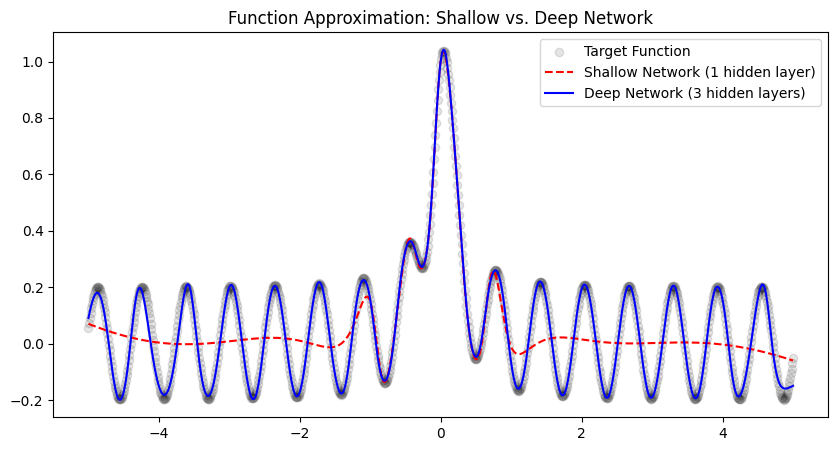

In [143]:
y_pred_shallow = shallow_net(x).detach()
y_pred_deep = deep_net(x).detach()

plt.figure(figsize=(10, 5))
plt.scatter(x, y, label="Target Function", color="black", alpha=0.1)
plt.plot(x, y_pred_shallow, label="Shallow Network (1 hidden layer)", linestyle="dashed", color="red")
plt.plot(x, y_pred_deep, label=f"Deep Network ({n_layers} hidden layers)", linestyle="solid", color="blue")
plt.legend()
plt.title("Function Approximation: Shallow vs. Deep Network")
plt.show()